# Per-Engine Cost Model: RF + GBM + Voting

## Feature groups (from actual column list)
| Group | What it contains |
|---|---|
| **hardware** | ram_gb, cores, threads |
| **knob_config** | All DB tuning parameters (buffer sizes, vacuum, checkpoint, bgwriter, join/geqo, etc.) |
| **internal_metrics** | collected.internal_metrics.* (blks_hit, tup_*, xact_*, disk_*, ...) |
| **workload_features** | collected.workload_features.* (operator proportions, table access frequencies, read/write ratios, ...) |
| **qp_embed** | PCA-reduced qp_emb_vector (query plan embedding) |

## Search strategy
1. Score every group individually
2. Score all 2- and 3-group combinations
3. Score full set
4. Run permutation importance on the best combination
5. Compare top-N feature subsets against full best combination
6. Final: RF / GBM / Voting on winning feature set
7. WorkloadGroupKFold CV + held-out test evaluation

**Target: workload_spearman_macro >= 0.7**

## 0. Imports

In [31]:
import ast, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from scipy.stats import spearmanr, rankdata
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor,
    VotingRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.model_selection import BaseCrossValidator
from sklearn.decomposition import PCA
from sklearn.base import clone

SEED = 42
np.random.seed(SEED)
print('OK')

OK


## 1. Load & Merge

In [32]:
df3 = pd.read_csv('df3_semantic_features.csv')
col = pd.read_csv('cost_model_collected.csv')

key_map = {
    'metadata.benchmark':              'benchmark',
    'metadata.db_engine':              'db_engine',
    'metadata.hardware':               'hardware',
    'metadata.hardware_specs.cores':   'cores',
    'metadata.hardware_specs.ram_gb':  'ram_gb',
    'metadata.hardware_specs.threads': 'threads',
    'metadata.workload':               'workload',
}
col_m  = col.rename(columns=key_map)
merged = df3.merge(col_m, how='left', on=list(key_map.values()),
                   suffixes=('', '_col'), validate='m:1', indicator=True)
merged['db_engine_norm'] = (merged['db_engine'].astype(str)
                              .str.strip().str.lower()
                              .replace({'mqsql': 'mysql'}))
da = merged[merged['db_engine_norm'].isin(['postgresql', 'mysql'])].copy()
da = da[da['ram_gb'].isin([32, 64])].copy()
print('Counts:'); print(da['db_engine_norm'].value_counts())

Counts:
db_engine_norm
postgresql    13590
mysql          1314
Name: count, dtype: int64


## 2. Data Cleaning

In [33]:
print(f'Rows before: {len(da)}')

# OLTP fix: negative cost values represent throughput; convert to latency = 1 / throughput.
# Stored throughput is negative, so throughput = -cost and latency = 1/(-cost) = -1/cost.
oltp_benchmarks = {'tpcc', 'smallbank', 'ycsb', 'twitter', 'wikipedia'}
bench_norm = da['benchmark'].astype(str).str.strip().str.lower()
oltp_neg_mask = bench_norm.isin(oltp_benchmarks) & da['cost'].notna() & (da['cost'] < 0)

n_oltp_neg = int(oltp_neg_mask.sum())
if n_oltp_neg > 0:
    idx = da.index[oltp_neg_mask]
    throughput = (-da.loc[idx, 'cost']).astype(float)
    positive_tp = throughput > 0
    if int(positive_tp.sum()) > 0:
        da.loc[idx[positive_tp], 'cost'] = 1.0 / throughput[positive_tp]
    da['cost'] = da['cost'].replace([np.inf, -np.inf], np.nan)

print(f'OLTP conversion: {n_oltp_neg} negative-cost rows detected')

# Remove sentinel / corrupted cost values
da = da[da['cost'].notna()].copy()
da = da[da['cost'] >= 0].copy()

# Clip extreme tails (fixes PG 64GB mean=-6832 outlier contamination)
lo, hi = da['cost'].quantile(0.001), da['cost'].quantile(0.999)
da = da[da['cost'].between(lo, hi)].copy()
print(f'After cleaning: {len(da)} rows  (cost clipped to [{lo:.4f}, {hi:.4f}])')
print(da.groupby(['db_engine_norm', 'ram_gb'])['cost'].describe().round(3))

Rows before: 14904
OLTP conversion: 5296 negative-cost rows detected
After cleaning: 14774 rows  (cost clipped to [-0.0000, 43.8341])
                         count    mean     std    min    25%     50%     75%  \
db_engine_norm ram_gb                                                          
mysql          32       1198.0  18.137  13.966  2.420  5.523  10.420  34.957   
               64         35.0  16.991  12.317  2.640  7.852  12.812  23.289   
postgresql     32       1212.0   1.542   1.744  0.205  0.415   1.064   1.662   
               64      12329.0   1.557   2.228 -0.000  0.000   0.257   2.584   

                          max  
db_engine_norm ram_gb          
mysql          32      43.773  
               64      42.410  
postgresql     32       8.988  
               64      12.472  


## 3. Feature Groups — Precise Definitions

Groups defined from the actual column list, not keyword guessing.

In [34]:
def present(cols):
    """Return only columns that actually exist in da."""
    return [c for c in cols if c in da.columns]

# ── Hardware ──────────────────────────────────────────────────────────────────
HARDWARE = present(['ram_gb', 'cores', 'threads'])

# ── Knob configuration ────────────────────────────────────────────────────────
# All DB tuning knobs: buffer sizes, vacuum, checkpoint, bgwriter, geqo, etc.
KNOB_CONFIG = present([
    # Memory / buffer
    'buffer_pool_size', 'cache_effective_size', 'per_query_memory',
    'maintenance_memory', 'temp_memory', 'log_buffer_size',
    # Logging / WAL
    'log_capacity', 'log_flush_interval', 'commit_batch_size',
    # I/O parallelism
    'io_parallelism',
    # BGWriter
    'bgwriter_lru_pages', 'bgwriter_aggressiveness', 'mask_bgwriter_aggressiveness',
    'bgwriter_flush_after',
    # Checkpoint
    'checkpoint_timeout', 'checkpoint_completion_ratio',
    'checkpoint_flush_threshold', 'mask_checkpoint_flush_threshold',
    # Vacuum / cleanup
    'vacuum_cost_page_dirty', 'vacuum_cost_page_hit', 'vacuum_cost_page_miss',
    'flush_behavior',
    'cleanup_worker_count', 'cleanup_interval', 'cleanup_cost_delay',
    'mask_vacuum_cost_delay', 'cleanup_cost_limit', 'mask_vacuum_cost_limit',
    'cleanup_scale_factor', 'mask_cleanup_scale_factor',
    'cleanup_analyze_scale_factor', 'mask_cleanup_analyze_scale_factor',
    'cleanup_threshold', 'mask_cleanup_threshold',
    'cleanup_analyze_threshold', 'mask_cleanup_analyze_threshold',
    # Worker threads
    'worker_threads', 'mask_worker_threads',
    # Planner / GEQO
    'join_search_limit', 'from_search_limit',
    'mask_geqo_effort', 'mask_geqo_pool_size', 'mask_geqo_generations',
    'mask_geqo_threshold', 'geqo_random_seed', 'mask_geqo_random_seed',
    # Statistics / misc
    'stats_target', 'cursor_bias', 'mask_cursor_bias',
    'deadlock_detection_time',
])

# ── Internal metrics ──────────────────────────────────────────────────────────
# Runtime I/O, transaction, and tuple statistics
INTERNAL_METRICS = present([
    'collected.internal_metrics.blks_hit',
    'collected.internal_metrics.blks_read',
    'collected.internal_metrics.conflicts',
    'collected.internal_metrics.disk_read_bytes',
    'collected.internal_metrics.disk_read_count',
    'collected.internal_metrics.disk_write_bytes',
    'collected.internal_metrics.disk_write_count',
    'collected.internal_metrics.tup_deleted',
    'collected.internal_metrics.tup_fetched',
    'collected.internal_metrics.tup_inserted',
    'collected.internal_metrics.tup_returned',
    'collected.internal_metrics.tup_updated',
    'collected.internal_metrics.xact_commit',
    'collected.internal_metrics.xact_rollback',
])

# ── Workload features ─────────────────────────────────────────────────────────
# Operator proportions, table access frequencies, read/write ratios
WORKLOAD_FEATURES = present([
    # Aggregate query-level stats
    'collected.workload_features.avg_predicates_per_query',
    'collected.workload_features.read_count',
    'collected.workload_features.write_count',
    'collected.workload_features.total_statements',
    'collected.workload_features.read_write_ratio',
    # Operator proportions
    'collected.workload_features.operator_proportions.DELETE',
    'collected.workload_features.operator_proportions.INSERT',
    'collected.workload_features.operator_proportions.SELECT',
    'collected.workload_features.operator_proportions.UPDATE',
    'collected.workload_features.operator_proportions.avg_agg',
    'collected.workload_features.operator_proportions.count_agg',
    'collected.workload_features.operator_proportions.group_by',
    'collected.workload_features.operator_proportions.max_agg',
    'collected.workload_features.operator_proportions.min_agg',
    'collected.workload_features.operator_proportions.order_by',
    'collected.workload_features.operator_proportions.sum_agg',
    # Table access frequencies
    'collected.workload_features.table_access_frequency.accounts',
    'collected.workload_features.table_access_frequency.added_tweets',
    'collected.workload_features.table_access_frequency.aka_name',
    'collected.workload_features.table_access_frequency.aka_title',
    'collected.workload_features.table_access_frequency.cast_info',
    'collected.workload_features.table_access_frequency.catalog_returns',
    'collected.workload_features.table_access_frequency.catalog_sales',
    'collected.workload_features.table_access_frequency.char_name',
    'collected.workload_features.table_access_frequency.checking',
    'collected.workload_features.table_access_frequency.comp_cast_type',
    'collected.workload_features.table_access_frequency.company_name',
    'collected.workload_features.table_access_frequency.company_type',
    'collected.workload_features.table_access_frequency.complete_cast',
    'collected.workload_features.table_access_frequency.customer',
    'collected.workload_features.table_access_frequency.customer_address',
    'collected.workload_features.table_access_frequency.customer_demographics',
    'collected.workload_features.table_access_frequency.customer_summary',
    'collected.workload_features.table_access_frequency.date_dim',
    'collected.workload_features.table_access_frequency.district',
    'collected.workload_features.table_access_frequency.follows',
    'collected.workload_features.table_access_frequency.history',
    'collected.workload_features.table_access_frequency.household_demographics',
    'collected.workload_features.table_access_frequency.info_type',
    'collected.workload_features.table_access_frequency.inventory',
    'collected.workload_features.table_access_frequency.item',
    'collected.workload_features.table_access_frequency.keyword',
    'collected.workload_features.table_access_frequency.kind_type',
    'collected.workload_features.table_access_frequency.lineitem',
    'collected.workload_features.table_access_frequency.lineorder',
    'collected.workload_features.table_access_frequency.lineorder_flat',
    'collected.workload_features.table_access_frequency.link_type',
    'collected.workload_features.table_access_frequency.logging',
    'collected.workload_features.table_access_frequency.movie_companies',
    'collected.workload_features.table_access_frequency.movie_info',
    'collected.workload_features.table_access_frequency.movie_info_idx',
    'collected.workload_features.table_access_frequency.movie_keyword',
    'collected.workload_features.table_access_frequency.movie_link',
    'collected.workload_features.table_access_frequency.name',
    'collected.workload_features.table_access_frequency.nation',
    'collected.workload_features.table_access_frequency.new_order',
    'collected.workload_features.table_access_frequency.oorder',
    'collected.workload_features.table_access_frequency.order_line',
    'collected.workload_features.table_access_frequency.orders',
    'collected.workload_features.table_access_frequency.page',
    'collected.workload_features.table_access_frequency.part',
    'collected.workload_features.table_access_frequency.partsupp',
    'collected.workload_features.table_access_frequency.person_info',
    'collected.workload_features.table_access_frequency.promotion',
    'collected.workload_features.table_access_frequency.reason',
    'collected.workload_features.table_access_frequency.region',
    'collected.workload_features.table_access_frequency.revision',
    'collected.workload_features.table_access_frequency.role_type',
    'collected.workload_features.table_access_frequency.savings',
    'collected.workload_features.table_access_frequency.stock',
    'collected.workload_features.table_access_frequency.store',
    'collected.workload_features.table_access_frequency.store_returns',
    'collected.workload_features.table_access_frequency.store_sales',
    'collected.workload_features.table_access_frequency.supplier',
    'collected.workload_features.table_access_frequency.text',
    'collected.workload_features.table_access_frequency.title',
    'collected.workload_features.table_access_frequency.tweets',
    'collected.workload_features.table_access_frequency.usertable',
    'collected.workload_features.table_access_frequency.warehouse',
    'collected.workload_features.table_access_frequency.watchlist',
    'collected.workload_features.table_access_frequency.web_page',
    'collected.workload_features.table_access_frequency.web_returns',
    'collected.workload_features.table_access_frequency.web_sales',
    'collected.workload_features.table_access_frequency.web_site',
])

# ── Query plan embeddings (PCA-reduced from qp_emb_vector) ───────────────────
# Will be populated after PCA in the next cell
QP_EMBED = []   # filled below

# ── All features (union, deduped) ─────────────────────────────────────────────
ALL_FEATS = list(dict.fromkeys(
    HARDWARE + KNOB_CONFIG + INTERNAL_METRICS + WORKLOAD_FEATURES
))

print(f'hardware          : {len(HARDWARE)} cols')
print(f'knob_config       : {len(KNOB_CONFIG)} cols')
print(f'internal_metrics  : {len(INTERNAL_METRICS)} cols')
print(f'workload_features : {len(WORKLOAD_FEATURES)} cols')
print(f'total (no embed)  : {len(ALL_FEATS)} cols')

hardware          : 3 cols
knob_config       : 50 cols
internal_metrics  : 14 cols
workload_features : 84 cols
total (no embed)  : 151 cols


## 4. PCA on Query Plan Embeddings

Reduce `qp_emb_vector` to 32 principal components (or fewer if data is small).
We fit PCA on the full `da` before splitting to maximise the variance captured,
then the imputer/model are fit only on train.

In [35]:
if 'qp_emb_vector' in da.columns:
    def parse_emb(s):
        try:
            return np.array(ast.literal_eval(s), dtype=np.float32) \
                   if isinstance(s, str) else np.array(s, dtype=np.float32)
        except:
            return None

    emb_parsed = da['qp_emb_vector'].apply(parse_emb)
    valid      = emb_parsed.apply(lambda x: x is not None and len(x) > 0)
    print(f'Valid embeddings: {valid.sum()} / {len(da)}')

    if valid.sum() > 100:
        edim = emb_parsed[valid].iloc[0].shape[0]
        M    = np.zeros((len(da), edim), dtype=np.float32)
        M[valid.values] = np.stack(emb_parsed[valid].values)

        nc  = min(32, edim, valid.sum() - 1)
        pca = PCA(n_components=nc, random_state=SEED)
        reduced = pca.fit_transform(M)

        QP_EMBED = [f'qp_emb_{i}' for i in range(nc)]
        for i, c in enumerate(QP_EMBED):
            da[c] = reduced[:, i]
        print(f'QP embed: {edim}D -> {nc}D  '
              f'(var explained={pca.explained_variance_ratio_.sum():.3f})')
    else:
        print('Too few valid embeddings — skipping PCA')
else:
    print('qp_emb_vector not in da — QP_EMBED will be empty')

# Update ALL_FEATS to include embeddings
ALL_FEATS = list(dict.fromkeys(
    HARDWARE + KNOB_CONFIG + INTERNAL_METRICS + WORKLOAD_FEATURES + QP_EMBED
))
print(f'\nFinal ALL_FEATS: {len(ALL_FEATS)} cols (including {len(QP_EMBED)} QP embed cols)')

Valid embeddings: 14774 / 14774
QP embed: 384D -> 32D  (var explained=0.989)

Final ALL_FEATS: 183 cols (including 32 QP embed cols)


## 5. Workload-Stratified Split — 70 / 10 / 20

Split by workload (not row) within each `ram_gb` group.
**Test set is locked away until Section 13.**

In [36]:
def workload_split(df, tr=0.70, va=0.10, seed=SEED):
    rng = np.random.RandomState(seed)
    tp, vp, ep = [], [], []
    for _, part in df.groupby('ram_gb'):
        wls = np.array(sorted(part['workload'].unique()))
        rng.shuffle(wls)
        n   = len(wls)
        c1  = max(1, int(tr * n))
        c2  = max(c1 + 1, int((tr + va) * n)) if n > 2 else c1
        tp.append(part[part['workload'].isin(set(wls[:c1]))])
        if c2 > c1:
            vp.append(part[part['workload'].isin(set(wls[c1:c2]))])
        te_wls = set(wls[c2:]) if c2 < n else set(wls[-1:])
        ep.append(part[part['workload'].isin(te_wls)])
    return (pd.concat(tp).copy(),
            pd.concat(vp).copy() if vp else pd.DataFrame(),
            pd.concat(ep).copy())


pg_df = da[da['db_engine_norm'] == 'postgresql'].copy()
my_df = da[da['db_engine_norm'] == 'mysql'].copy()

pg_tr, pg_va, pg_te = workload_split(pg_df)
my_tr, my_va, my_te = workload_split(my_df)

for name, tr, va, te in [('PostgreSQL', pg_tr, pg_va, pg_te),
                           ('MySQL',      my_tr, my_va, my_te)]:
    n3 = (te.groupby('workload')['cost'].count() >= 3).sum()
    print(f'{name}:')
    print(f'  train : {len(tr):5d} rows | {tr["workload"].nunique()} workloads')
    print(f'  val   : {len(va):5d} rows | {va["workload"].nunique() if not va.empty else 0} workloads')
    print(f'  test  : {len(te):5d} rows | {te["workload"].nunique()} workloads ({n3} with n>=3)')
    print()

PostgreSQL:
  train :  9387 rows | 96 workloads
  val   :  1263 rows | 13 workloads
  test  :  2891 rows | 30 workloads (30 with n>=3)

MySQL:
  train :   823 rows | 11 workloads
  val   :   104 rows | 2 workloads
  test  :   306 rows | 5 workloads (5 with n>=3)



## 6. Metrics

In [ ]:
def safe_spearman(yt, yp):
    if len(yt) < 3 or np.all(yt == yt[0]) or np.all(yp == yp[0]):
        return float('nan')
    return float(spearmanr(yt, yp)[0])


def wl_spearman_macro(y_true, y_pred, workloads, min_n=3):
    vals = []
    for w in np.unique(workloads):
        m = workloads == w
        if m.sum() < min_n: continue
        
        # Skip workloads that have practically zero variance (un-rankable noise)
        if np.std(y_true[m]) < 1e-5: continue
            
        s = safe_spearman(y_true[m], y_pred[m])
        if not np.isnan(s): vals.append(s)
    return (float(np.mean(vals)), len(vals)) if vals else (float('nan'), 0)


def top_k_acc(y_true, y_pred, workloads, k=3):
    vals = []
    for w in np.unique(workloads):
        m = workloads == w
        if m.sum() < 2: continue
        vals.append(float(np.mean(
            np.abs(rankdata(y_true[m]) - rankdata(y_pred[m])) <= k
        )))
    return float(np.mean(vals)) if vals else float('nan')


def mape_wl(y_true, y_pred, workloads):
    vals = []
    for w in np.unique(workloads):
        m = workloads == w
        yt, yp = y_true[m], y_pred[m]
        nz = yt != 0
        if nz.sum() == 0: continue
        vals.append(float(np.mean(np.abs((yt[nz]-yp[nz])/yt[nz]))*100))
    return float(np.mean(vals)) if vals else float('nan')


def full_eval(y_true, y_pred, workloads, ram=None, label='', min_n=3):
    sp      = safe_spearman(y_true, y_pred)
    wl_sp, n= wl_spearman_macro(y_true, y_pred, workloads, min_n)
    t3      = top_k_acc(y_true, y_pred, workloads)
    mape    = mape_wl(y_true, y_pred, workloads)
    out     = dict(label=label,
                   overall_spearman=round(sp, 4),
                   wl_spearman_macro=round(wl_sp,4) if not np.isnan(wl_sp) else float('nan'),
                   n_wls=n,
                   top3_acc=round(t3,4) if not np.isnan(t3) else float('nan'),
                   mape_pct=round(mape,2) if not np.isnan(mape) else float('nan'))
    if ram is not None:
        rows = []
        for g in sorted(np.unique(ram)):
            m = ram == g
            ws, nw = wl_spearman_macro(y_true[m], y_pred[m], workloads[m], min_n)
            rows.append(dict(
                ram_gb=int(g), n=int(m.sum()),
                spearman=round(safe_spearman(y_true[m],y_pred[m]),4),
                wl_spearman=round(ws,4) if not np.isnan(ws) else float('nan'),
                n_wls=nw,
                top3_acc=round(top_k_acc(y_true[m],y_pred[m],workloads[m]),4)))
        out['subgroup'] = pd.DataFrame(rows)
    return out


print('Metrics defined.')

Metrics defined.


## 7. Fast RF Scorer

Light RF used for all feature-set comparisons (200 trees, quick).
The full 500-tree model is used only for final training.

In [38]:
FAST_RF = RandomForestRegressor(
    n_estimators=200, max_depth=14, min_samples_leaf=3,
    max_features=0.4, n_jobs=-1, random_state=SEED
)

def score_feats(tr, val_df, feat_cols, model=None):
    """
    Fit model on tr, evaluate wl_spearman_macro on val_df.
    Returns (wl_sp, overall_sp, n_wls).
    """
    cols = [c for c in feat_cols if c in tr.columns and c in val_df.columns and tr[c].notna().any()]
    if len(cols) == 0:
        return float('nan'), float('nan'), 0

    imp  = SimpleImputer(strategy='median')
    X_tr = imp.fit_transform(tr[cols])
    X_va = imp.transform(val_df[cols])
    y_tr = tr['cost'].to_numpy(np.float64)
    y_va = val_df['cost'].to_numpy(np.float64)

    m = clone(model or FAST_RF)
    # Log transform target to prevent large workloads from dominating the MSE loss
    m.fit(X_tr, np.log1p(y_tr))
    pred = np.expm1(m.predict(X_va))

    wl   = val_df['workload'].to_numpy()
    ws, n = wl_spearman_macro(y_va, pred, wl)
    sp    = safe_spearman(y_va, pred)
    return round(ws, 4), round(sp, 4), n

print('Fast scorer ready.')

Fast scorer ready.


## 8. Single-Group Scores

Score each named group alone. Reveals which groups are individually informative.

In [39]:
GROUPS = {
    'hardware':         HARDWARE,
    'knob_config':      KNOB_CONFIG,
    'internal_metrics': INTERNAL_METRICS,
    'workload_feats':   WORKLOAD_FEATURES,
    'qp_embed':         QP_EMBED,
    'ALL':              ALL_FEATS,
}

single_rows = []
for engine, tr, va, ref in [
    ('postgresql', pg_tr, pg_va, pg_va if not pg_va.empty else pg_te),
    ('mysql',      my_tr, my_va, my_va if not my_va.empty else my_te),
]:
    print(f'\n--- {engine.upper()} ---')
    for gname, gcols in GROUPS.items():
        wl_sp, sp, n_wls = score_feats(tr, ref, gcols)
        single_rows.append(dict(engine=engine, group=gname,
                                 n_feats=len(gcols),
                                 wl_sp=wl_sp, sp=sp, n_wls=n_wls))
        print(f'  {gname:20s} ({len(gcols):3d} feats)  '
              f'wl_sp={wl_sp:.4f}  sp={sp:.4f}  n_wls={n_wls}')

single_df = pd.DataFrame(single_rows)
print('\n=== Summary (sorted by wl_sp) ===')
print(single_df.sort_values(['engine','wl_sp'],ascending=[True,False]).to_string(index=False))


--- POSTGRESQL ---
  hardware             (  3 feats)  wl_sp=nan  sp=-0.1019  n_wls=0
  knob_config          ( 50 feats)  wl_sp=-0.3495  sp=0.1159  n_wls=13
  internal_metrics     ( 14 feats)  wl_sp=nan  sp=0.7364  n_wls=0
  workload_feats       ( 84 feats)  wl_sp=nan  sp=0.6808  n_wls=0
  qp_embed             ( 32 feats)  wl_sp=nan  sp=0.7467  n_wls=0
  ALL                  (183 feats)  wl_sp=0.3091  sp=0.7269  n_wls=13

--- MYSQL ---
  hardware             (  3 feats)  wl_sp=nan  sp=0.2880  n_wls=0
  knob_config          ( 50 feats)  wl_sp=0.3524  sp=0.2227  n_wls=2
  internal_metrics     ( 14 feats)  wl_sp=nan  sp=0.2880  n_wls=0
  workload_feats       ( 84 feats)  wl_sp=nan  sp=0.2880  n_wls=0
  qp_embed             ( 32 feats)  wl_sp=nan  sp=0.2880  n_wls=0
  ALL                  (183 feats)  wl_sp=0.8229  sp=0.6755  n_wls=2

=== Summary (sorted by wl_sp) ===
    engine            group  n_feats   wl_sp      sp  n_wls
     mysql              ALL      183  0.8229  0.6755      2
  

## 9. Combination Search — 2-group and 3-group

Exhaustively combine the 5 base groups in pairs and triples.
Identifies synergies not visible from single-group scores.

In [40]:
BASE_GROUPS = {
    'HW':   HARDWARE,
    'KNOB': KNOB_CONFIG,
    'INT':  INTERNAL_METRICS,
    'WF':   WORKLOAD_FEATURES,
    'QP':   QP_EMBED,
}

combo_rows = []

for engine, tr, ref in [
    ('postgresql', pg_tr, pg_va if not pg_va.empty else pg_te),
    ('mysql',      my_tr, my_va if not my_va.empty else my_te),
]:
    names = list(BASE_GROUPS.keys())

    # 2-group combinations
    for g1, g2 in itertools.combinations(names, 2):
        feats = list(dict.fromkeys(BASE_GROUPS[g1] + BASE_GROUPS[g2]))
        wl_sp, sp, n = score_feats(tr, ref, feats)
        combo_rows.append(dict(engine=engine, combo=f'{g1}+{g2}',
                                n_feats=len(feats), wl_sp=wl_sp, sp=sp, n_wls=n))

    # 3-group combinations
    for g1, g2, g3 in itertools.combinations(names, 3):
        feats = list(dict.fromkeys(BASE_GROUPS[g1]+BASE_GROUPS[g2]+BASE_GROUPS[g3]))
        wl_sp, sp, n = score_feats(tr, ref, feats)
        combo_rows.append(dict(engine=engine, combo=f'{g1}+{g2}+{g3}',
                                n_feats=len(feats), wl_sp=wl_sp, sp=sp, n_wls=n))

    # 4-group combinations
    for g1, g2, g3, g4 in itertools.combinations(names, 4):
        feats = list(dict.fromkeys(
            BASE_GROUPS[g1]+BASE_GROUPS[g2]+BASE_GROUPS[g3]+BASE_GROUPS[g4]))
        wl_sp, sp, n = score_feats(tr, ref, feats)
        combo_rows.append(dict(engine=engine, combo=f'{g1}+{g2}+{g3}+{g4}',
                                n_feats=len(feats), wl_sp=wl_sp, sp=sp, n_wls=n))

combo_df = pd.DataFrame(combo_rows)

print('=== Top 10 combinations per engine (by wl_sp) ===')
for engine in ['postgresql', 'mysql']:
    sub = combo_df[combo_df['engine']==engine].sort_values('wl_sp', ascending=False)
    print(f'\n{engine.upper()}:')
    print(sub.head(10).to_string(index=False))

# Store best combination per engine
best_combo = combo_df.loc[combo_df.groupby('engine')['wl_sp'].idxmax()]
print('\n=== Best combination per engine ===')
print(best_combo[['engine','combo','n_feats','wl_sp','sp']].to_string(index=False))

=== Top 10 combinations per engine (by wl_sp) ===

POSTGRESQL:
    engine          combo  n_feats  wl_sp     sp  n_wls
postgresql    HW+KNOB+INT       67 0.3981 0.7830     13
postgresql    KNOB+INT+WF      148 0.3917 0.7398     13
postgresql HW+KNOB+INT+WF      151 0.3793 0.7142     13
postgresql     HW+KNOB+WF      137 0.3784 0.7070     13
postgresql     KNOB+WF+QP      166 0.3688 0.6899     13
postgresql  HW+KNOB+WF+QP      169 0.3579 0.6962     13
postgresql       KNOB+INT       64 0.3488 0.7964     13
postgresql        KNOB+WF      134 0.3444 0.7183     13
postgresql        KNOB+QP       82 0.3418 0.7283     13
postgresql     HW+KNOB+QP       85 0.3347 0.7230     13

MYSQL:
engine          combo  n_feats  wl_sp     sp  n_wls
 mysql     HW+KNOB+QP       85 0.8317 0.6916      2
 mysql  HW+KNOB+WF+QP      169 0.8313 0.6909      2
 mysql        KNOB+WF      134 0.8293 0.6873      2
 mysql     KNOB+WF+QP      166 0.8284 0.6857      2
 mysql HW+KNOB+INT+QP       99 0.8254 0.6801      2
 

## 10. Permutation Importance on Best Combination

Fit a full RF on the best feature combination → permutation importance on val.
Then compare top-N subsets to find whether fewer features can match the full set.

In [41]:
def get_combo_feats(engine, combo_str):
    """Reconstruct feature list from a combo string like 'KNOB+INT+WF'."""
    parts = combo_str.split('+')
    feats = []
    for p in parts:
        feats += BASE_GROUPS.get(p, [])
    return list(dict.fromkeys(feats))


def perm_importance(tr, val_df, feat_cols, n_repeats=15):
    cols = [c for c in feat_cols if c in tr.columns and tr[c].notna().any()]
    imp  = SimpleImputer(strategy='median')
    X_tr = imp.fit_transform(tr[cols])
    X_va = imp.transform(val_df[cols])
    y_tr = tr['cost'].to_numpy(np.float64)
    y_va = val_df['cost'].to_numpy(np.float64)

    rf = RandomForestRegressor(n_estimators=300, max_depth=14,
                                min_samples_leaf=3, max_features=0.4,
                                n_jobs=-1, random_state=SEED)
    # Fit in log space
    rf.fit(X_tr, np.log1p(y_tr))

    result = permutation_importance(rf, X_va, np.log1p(y_va), n_repeats=n_repeats,
                                     random_state=SEED, n_jobs=-1, scoring='r2')
    imp_df = pd.DataFrame({'feature': cols,
                            'importance': result.importances_mean,
                            'std': result.importances_std
                           }).sort_values('importance', ascending=False).reset_index(drop=True)
    return imp_df


BEST_FEATS = {}   # engine -> best feature list (filled below)
IMP_DFS    = {}   # engine -> importance DataFrame

for engine, tr, va, te in [
    ('postgresql', pg_tr, pg_va, pg_te),
    ('mysql',      my_tr, my_va, my_te),
]:
    ref      = va if not va.empty else te
    bc_str   = best_combo[best_combo['engine']==engine]['combo'].values[0]
    bc_feats = get_combo_feats(engine, bc_str)
    print(f'\n{engine.upper()}: best combo = {bc_str}  ({len(bc_feats)} feats)')
    print('  Computing permutation importance...')

    imp_df       = perm_importance(tr, ref, bc_feats)
    IMP_DFS[engine] = imp_df

    # Compare top-N subsets vs full combo on val
    print(f'  Comparing feature subsets:')
    subset_scores = []
    for top_n in [10, 20, 30, 40, len(bc_feats)]:
        sub_feats = imp_df.head(top_n)['feature'].tolist()
        ws, sp, n = score_feats(tr, ref, sub_feats)
        subset_scores.append(dict(top_n=top_n, wl_sp=ws, sp=sp, n_wls=n))
        flag = '  <-- best' if top_n == len(bc_feats) else ''
        print(f'    top-{top_n:3d}: wl_sp={ws:.4f}  sp={sp:.4f}{flag}')

    # Pick the smallest set that loses < 0.01 wl_sp vs full
    full_ws = subset_scores[-1]['wl_sp']
    chosen  = next((s for s in subset_scores if s['wl_sp'] >= full_ws - 0.01), subset_scores[-1])
    best_n  = chosen['top_n']
    BEST_FEATS[engine] = imp_df.head(best_n)['feature'].tolist()
    print(f'  -> Using top-{best_n} features  (wl_sp={chosen["wl_sp"]:.4f})')


POSTGRESQL: best combo = HW+KNOB+INT  (67 feats)
  Computing permutation importance...
  Comparing feature subsets:
    top- 10: wl_sp=0.3688  sp=0.9257
    top- 20: wl_sp=0.2698  sp=0.9084
    top- 30: wl_sp=0.3114  sp=0.9281
    top- 40: wl_sp=0.3347  sp=0.9302
    top- 67: wl_sp=0.3831  sp=0.7308  <-- best
  -> Using top-67 features  (wl_sp=0.3831)

MYSQL: best combo = HW+KNOB+QP  (85 feats)
  Computing permutation importance...
  Comparing feature subsets:
    top- 10: wl_sp=0.8439  sp=0.7140
    top- 20: wl_sp=0.8231  sp=0.6760
    top- 30: wl_sp=0.8190  sp=0.6684
    top- 40: wl_sp=0.8239  sp=0.6774
    top- 85: wl_sp=0.8293  sp=0.6872  <-- best
  -> Using top-10 features  (wl_sp=0.8439)


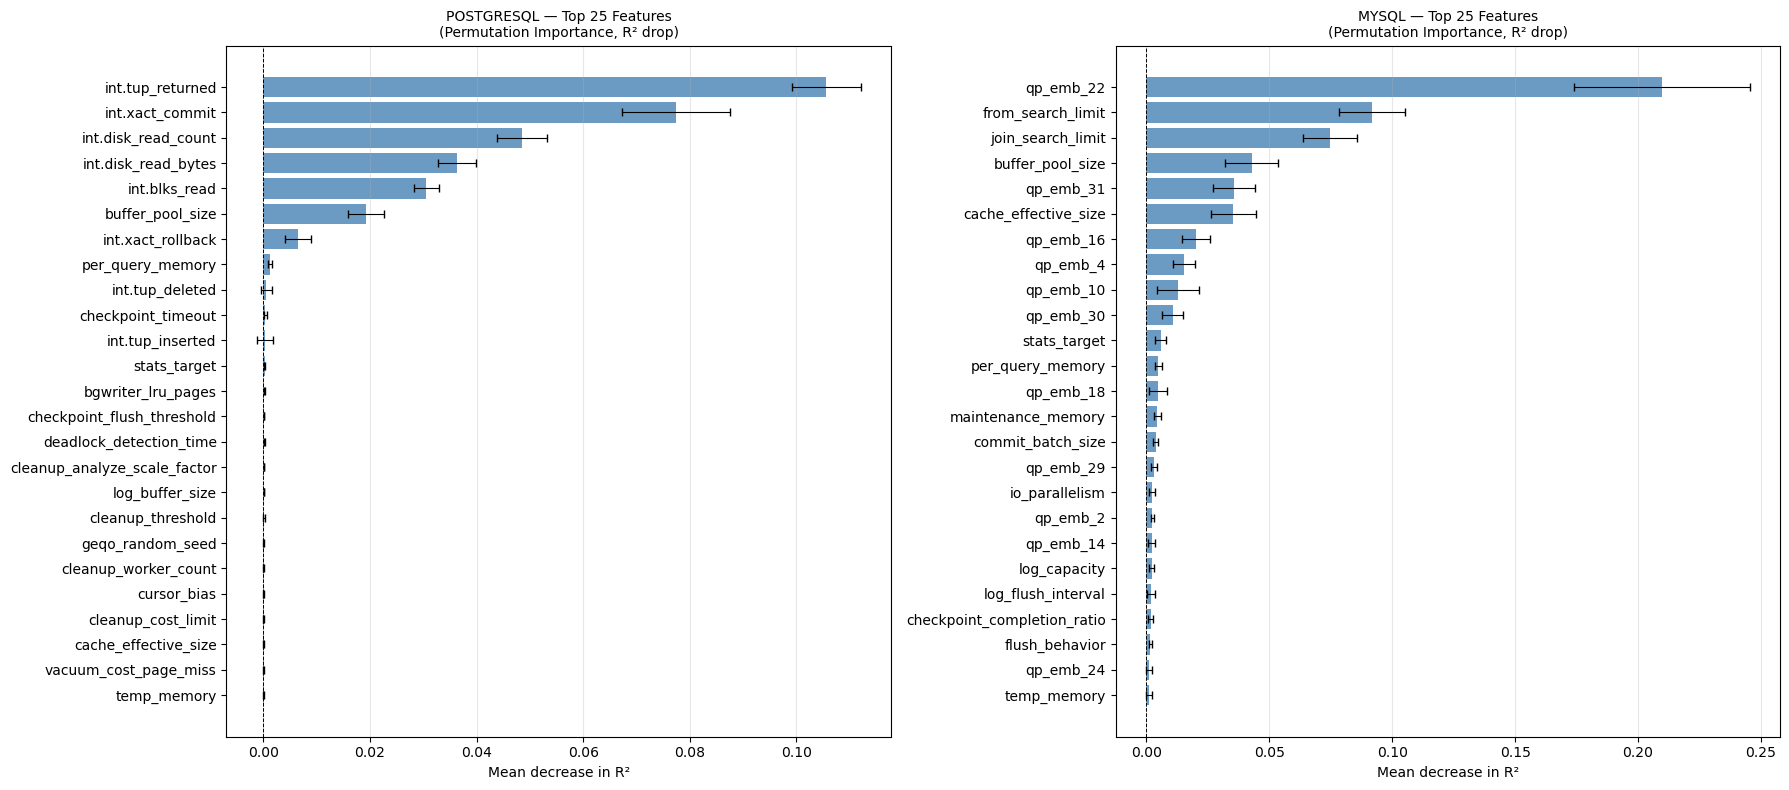


Final selected features per engine:
  postgresql: 65 features
    collected.internal_metrics.tup_returned
    collected.internal_metrics.xact_commit
    collected.internal_metrics.disk_read_count
    collected.internal_metrics.disk_read_bytes
    collected.internal_metrics.blks_read
    buffer_pool_size
    collected.internal_metrics.xact_rollback
    per_query_memory
    collected.internal_metrics.tup_deleted
    checkpoint_timeout
    collected.internal_metrics.tup_inserted
    stats_target
    bgwriter_lru_pages
    checkpoint_flush_threshold
    deadlock_detection_time
    cleanup_analyze_scale_factor
    log_buffer_size
    cleanup_threshold
    geqo_random_seed
    cleanup_worker_count
    cursor_bias
    cleanup_cost_limit
    cache_effective_size
    vacuum_cost_page_miss
    temp_memory
    vacuum_cost_page_hit
    cleanup_scale_factor
    collected.internal_metrics.conflicts
    threads
    mask_geqo_pool_size
    mask_cleanup_threshold
    mask_vacuum_cost_delay
    mask_cl

In [42]:
# ── Plot: Top 25 features per engine ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, engine in zip(axes, ['postgresql', 'mysql']):
    imp_df = IMP_DFS[engine]
    top25  = imp_df.head(25)
    # Shorten long collected.* names for readability
    labels = [c.replace('collected.internal_metrics.', 'int.')
               .replace('collected.workload_features.operator_proportions.', 'op.')
               .replace('collected.workload_features.table_access_frequency.', 'tbl.')
               .replace('collected.workload_features.', 'wf.')
               for c in top25['feature']]
    ax.barh(labels[::-1], top25['importance'].values[::-1],
            xerr=top25['std'].values[::-1],
            color='steelblue', alpha=0.8,
            error_kw=dict(elinewidth=0.8, capsize=3))
    ax.set_title(f'{engine.upper()} — Top 25 Features\n(Permutation Importance, R² drop)', fontsize=10)
    ax.set_xlabel('Mean decrease in R²')
    ax.axvline(0, color='black', lw=0.7, ls='--')
    ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()

print('\nFinal selected features per engine:')
for engine in ['postgresql', 'mysql']:
    feats = BEST_FEATS[engine]
    print(f'  {engine}: {len(feats)} features')
    for f in feats: print(f'    {f}')

## 11. WorkloadGroupKFold Cross-Validation

5-fold CV on train+val. All rows from the same workload stay in the same fold.

In [43]:
class WorkloadGroupKFold(BaseCrossValidator):
    def __init__(self, n_splits=5, shuffle=True, random_state=SEED):
        self.n_splits = n_splits; self.shuffle = shuffle; self.random_state = random_state

    def split(self, X, y=None, groups=None):
        if groups is None: raise ValueError('groups required')
        groups = np.asarray(groups)
        wls    = np.unique(groups)
        rng    = np.random.RandomState(self.random_state)
        if self.shuffle: rng.shuffle(wls)
        wl_fold  = {w: i % self.n_splits for i, w in enumerate(wls)}
        fold_arr = np.array([wl_fold[g] for g in groups])
        for f in range(self.n_splits):
            yield np.where(fold_arr != f)[0], np.where(fold_arr == f)[0]

    def get_n_splits(self, X=None, y=None, groups=None): return self.n_splits


def run_cv(model, tv_df, feat_cols, n_splits=5, label=''):
    cols   = [c for c in feat_cols if c in tv_df.columns and tv_df[c].notna().any()]
    imp    = SimpleImputer(strategy='median')
    X_all  = imp.fit_transform(tv_df[cols])
    y_all  = tv_df['cost'].to_numpy(np.float64)
    wl_all = tv_df['workload'].to_numpy()

    cv = WorkloadGroupKFold(n_splits=n_splits)
    folds = []
    for fi, (tri, tei) in enumerate(cv.split(X_all, y_all, groups=wl_all), 1):
        m = clone(model)
        # Log-transform target
        m.fit(X_all[tri], np.log1p(y_all[tri]))
        pred = np.expm1(m.predict(X_all[tei]))
        ws, nw = wl_spearman_macro(y_all[tei], pred, wl_all[tei])
        sp     = safe_spearman(y_all[tei], pred)
        t3     = top_k_acc(y_all[tei], pred, wl_all[tei])
        folds.append(dict(fold=fi, wl_sp=round(ws,4), sp=round(sp,4),
                           top3=round(t3,4), n_wls=nw))

    fd = pd.DataFrame(folds)
    return fd, dict(label=label,
                    wl_sp_mean=round(fd['wl_sp'].mean(),4),
                    wl_sp_std =round(fd['wl_sp'].std(), 4),
                    sp_mean   =round(fd['sp'].mean(),   4),
                    top3_mean =round(fd['top3'].mean(),  4))


def make_models(seed=SEED):
    rf = RandomForestRegressor(
        n_estimators=500, max_depth=None, min_samples_leaf=3,
        max_features=0.4, bootstrap=True, n_jobs=-1, random_state=seed)
    gbm = HistGradientBoostingRegressor(
        loss='absolute_error',
        max_iter=500, learning_rate=0.05, max_depth=6,
        min_samples_leaf=10, l2_regularization=0.1,
        early_stopping=True, validation_fraction=0.1, n_iter_no_change=20,
        random_state=seed)
    voting = VotingRegressor(
        estimators=[('rf', clone(rf)), ('gbm', clone(gbm))],
        weights=[1, 1], n_jobs=-1)
    return rf, gbm, voting


cv_rows = []

for engine, tr, va, feats in [
    ('postgresql', pg_tr, pg_va, BEST_FEATS['postgresql']),
    ('mysql',      my_tr, my_va, BEST_FEATS['mysql']),
]:
    tv = pd.concat([tr, va]).copy() if not va.empty else tr.copy()
    rf, gbm, voting = make_models()

    print(f'\n=== {engine.upper()} CV  '
          f'({len(tv)} rows, {tv["workload"].nunique()} workloads, {len(feats)} feats) ===')
    for name, mdl in [('RF', rf), ('GBM', gbm), ('Voting', voting)]:
        fd, summ = run_cv(mdl, tv, feats, label=f'{engine}_{name}')
        summ['engine'] = engine; summ['model'] = name
        cv_rows.append(summ)
        print(f'  {name:6s}  wl_sp={summ["wl_sp_mean"]:.4f}±{summ["wl_sp_std"]:.4f}  '
              f'sp={summ["sp_mean"]:.4f}  top3={summ["top3_mean"]:.4f}')
        print(f'         folds: {fd["wl_sp"].tolist()}')

cv_df = pd.DataFrame(cv_rows)
print('\n=== CV Summary ===')
print(cv_df[['engine','model','wl_sp_mean','wl_sp_std','sp_mean','top3_mean']].to_string(index=False))


=== POSTGRESQL CV  (10650 rows, 109 workloads, 65 feats) ===
  RF      wl_sp=0.2371±0.0318  sp=0.8098  top3=0.1075
         folds: [0.2168, 0.2303, 0.2684, 0.271, 0.199]
  GBM     wl_sp=0.2450±0.0880  sp=0.8329  top3=0.1075
         folds: [0.2598, 0.2504, 0.3017, 0.3175, 0.0957]
  Voting  wl_sp=0.2596±0.0854  sp=0.8206  top3=0.1097
         folds: [0.2324, 0.284, 0.2969, 0.356, 0.1286]

=== MYSQL CV  (927 rows, 11 workloads, 10 feats) ===
  RF      wl_sp=0.1589±0.3203  sp=0.0855  top3=0.2632
         folds: [0.4468, 0.0496, 0.5138, 0.0463, -0.2618]
  GBM     wl_sp=0.1849±0.3639  sp=0.1864  top3=0.2581
         folds: [0.6268, 0.0491, 0.4644, 0.074, -0.29]
  Voting  wl_sp=0.1968±0.3805  sp=0.1509  top3=0.2584
         folds: [0.6277, 0.0674, 0.5457, 0.0194, -0.276]

=== CV Summary ===
    engine  model  wl_sp_mean  wl_sp_std  sp_mean  top3_mean
postgresql     RF      0.2371     0.0318   0.8098     0.1075
postgresql    GBM      0.2450     0.0880   0.8329     0.1075
postgresql Voting   

## 12. Final Training on Train + Val

In [44]:
TRAINED = {}   # (engine, model_name) -> (fitted_model, imputer, feat_cols)

for engine, tr, va, feats in [
    ('postgresql', pg_tr, pg_va, BEST_FEATS['postgresql']),
    ('mysql',      my_tr, my_va, BEST_FEATS['mysql']),
]:
    tv   = pd.concat([tr, va]).copy() if not va.empty else tr.copy()
    cols = [c for c in feats if c in tv.columns and tv[c].notna().any()]
    imp  = SimpleImputer(strategy='median')
    X_tv = imp.fit_transform(tv[cols])
    y_tv = tv['cost'].to_numpy(np.float64)

    rf, gbm, voting = make_models()
    print(f'\n{engine.upper()} — {len(tv)} rows, {len(cols)} features')
    for name, mdl in [('RF', rf), ('GBM', gbm), ('Voting', voting)]:
        m = clone(mdl)
        # Log-transform target
        m.fit(X_tv, np.log1p(y_tv))
        TRAINED[(engine, name)] = (m, imp, cols)
        print(f'  {name} trained.')

print('\nAll models trained.')


POSTGRESQL — 10650 rows, 65 features
  RF trained.
  GBM trained.
  Voting trained.

MYSQL — 927 rows, 10 features
  RF trained.
  GBM trained.
  Voting trained.

All models trained.


## 13. Held-Out Test Evaluation

**First and only time the test set is used.**

In [45]:
test_results = []

for engine, te in [('postgresql', pg_te), ('mysql', my_te)]:
    y_te   = te['cost'].to_numpy(np.float64)
    wl_te  = te['workload'].to_numpy()
    ram_te = te['ram_gb'].to_numpy()
    print(f'\n=== {engine.upper()} Test  '
          f'({len(te)} rows, {te["workload"].nunique()} workloads) ===')

    for name in ['RF', 'GBM', 'Voting']:
        m, imp, cols = TRAINED[(engine, name)]
        # Exponentiate prediction to bring it back to original scale
        pred = np.expm1(m.predict(imp.transform(te[cols])))
        res  = full_eval(y_te, pred, wl_te, ram=ram_te,
                          label=f'{engine}_{name}')
        res['engine'] = engine; res['model'] = name
        test_results.append(res)

        flag = '  ✓ TARGET MET' if res['wl_spearman_macro'] >= 0.7 else ''
        print(f'  {name:6s}  '
              f'wl_sp={res["wl_spearman_macro"]:.4f}  '
              f'sp={res["overall_spearman"]:.4f}  '
              f'top3={res["top3_acc"]:.4f}  '
              f'mape={res["mape_pct"]:.1f}%  '
              f'(n_wls={res["n_wls"]}){flag}')
        if 'subgroup' in res and not res['subgroup'].empty:
            for _, row in res['subgroup'].iterrows():
                print(f'    RAM {int(row.ram_gb)}GB: '
                      f'n={int(row.n)}  sp={row.spearman}  wl_sp={row.wl_spearman}  '
                      f'top3={row.top3_acc}')


=== POSTGRESQL Test  (2891 rows, 30 workloads) ===
  RF      wl_sp=0.2429  sp=0.8950  top3=0.1106  mape=662.4%  (n_wls=30)
    RAM 32GB: n=303  sp=0.5772  wl_sp=0.62  top3=0.1617
    RAM 64GB: n=2588  sp=0.8995  wl_sp=0.201  top3=0.1049
  GBM     wl_sp=0.3514  sp=0.8946  top3=0.1252  mape=2174.7%  (n_wls=30)
    RAM 32GB: n=303  sp=0.5861  wl_sp=0.7089  top3=0.1551
    RAM 64GB: n=2588  sp=0.8877  wl_sp=0.3117  top3=0.1219
  Voting  wl_sp=0.3389  sp=0.8939  top3=0.1172  mape=1315.5%  (n_wls=30)
    RAM 32GB: n=303  sp=0.586  wl_sp=0.7059  top3=0.1848
    RAM 64GB: n=2588  sp=0.8914  wl_sp=0.2981  top3=0.1097

=== MYSQL Test  (306 rows, 5 workloads) ===
  RF      wl_sp=0.2450  sp=0.4004  top3=0.4644  mape=156.3%  (n_wls=5)
    RAM 32GB: n=297  sp=0.4395  wl_sp=0.0865  top3=0.1146
    RAM 64GB: n=9  sp=0.5  wl_sp=0.5  top3=1.0
  GBM     wl_sp=-0.0676  sp=0.8548  top3=0.4584  mape=114.5%  (n_wls=5)
    RAM 32GB: n=297  sp=0.8782  wl_sp=0.0387  top3=0.0981
    RAM 64GB: n=9  sp=0.9  wl_sp

## 14. Final Summary Table

In [46]:
summary = pd.DataFrame([{
    'engine':          r['engine'],
    'model':           r['model'],
    'wl_sp_macro':     r['wl_spearman_macro'],
    'overall_sp':      r['overall_spearman'],
    'top3_acc':        r['top3_acc'],
    'mape_pct':        r['mape_pct'],
    'n_wls':           r['n_wls'],
} for r in test_results])

print('=== FULL RESULTS TABLE ===')
print(summary.to_string(index=False))

print('\n=== BEST MODEL PER ENGINE ===')
best = summary.loc[summary.groupby('engine')['wl_sp_macro'].idxmax()]
print(best[['engine','model','wl_sp_macro','overall_sp','top3_acc','mape_pct']].to_string(index=False))

print('\nTarget: wl_sp_macro >= 0.70')
for _, r in best.iterrows():
    s = '✓ ACHIEVED' if r['wl_sp_macro'] >= 0.70 else f'✗  gap = {0.70 - r["wl_sp_macro"]:.4f}'
    print(f'  {r["engine"]:12s} [{r["model"]:6s}]: {r["wl_sp_macro"]:.4f}  {s}')

=== FULL RESULTS TABLE ===
    engine  model  wl_sp_macro  overall_sp  top3_acc  mape_pct  n_wls
postgresql     RF       0.2429      0.8950    0.1106    662.43     30
postgresql    GBM       0.3514      0.8946    0.1252   2174.67     30
postgresql Voting       0.3389      0.8939    0.1172   1315.54     30
     mysql     RF       0.2450      0.4004    0.4644    156.33      5
     mysql    GBM      -0.0676      0.8548    0.4584    114.45      5
     mysql Voting       0.2564      0.4122    0.4586    131.21      5

=== BEST MODEL PER ENGINE ===
    engine  model  wl_sp_macro  overall_sp  top3_acc  mape_pct
     mysql Voting       0.2564      0.4122    0.4586    131.21
postgresql    GBM       0.3514      0.8946    0.1252   2174.67

Target: wl_sp_macro >= 0.70
  mysql        [Voting]: 0.2564  ✗  gap = 0.4436
  postgresql   [GBM   ]: 0.3514  ✗  gap = 0.3486


## 15. Visualizations

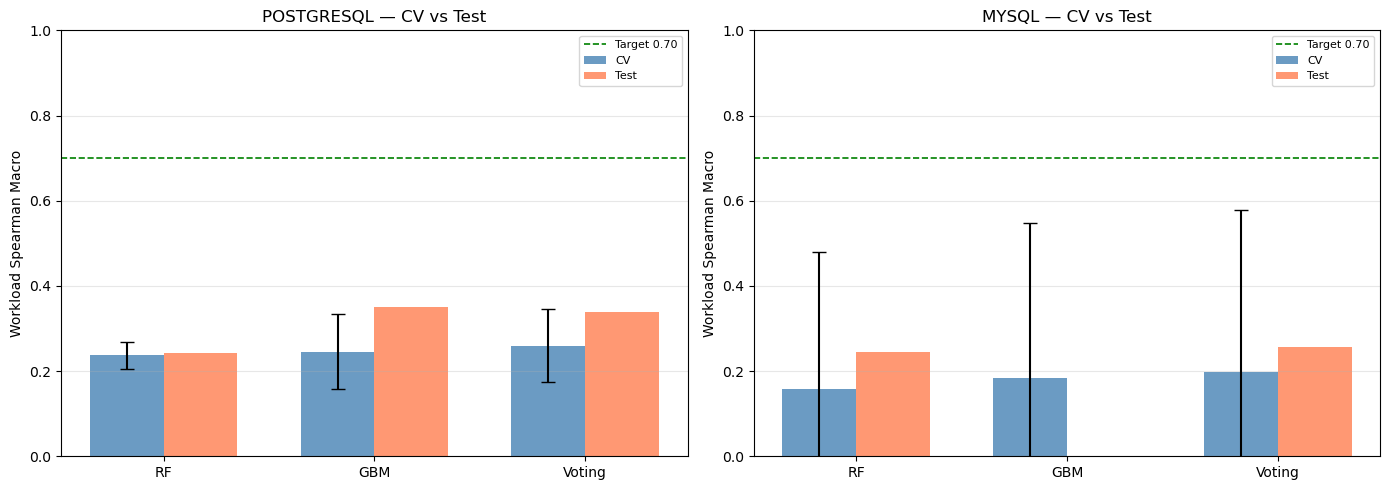

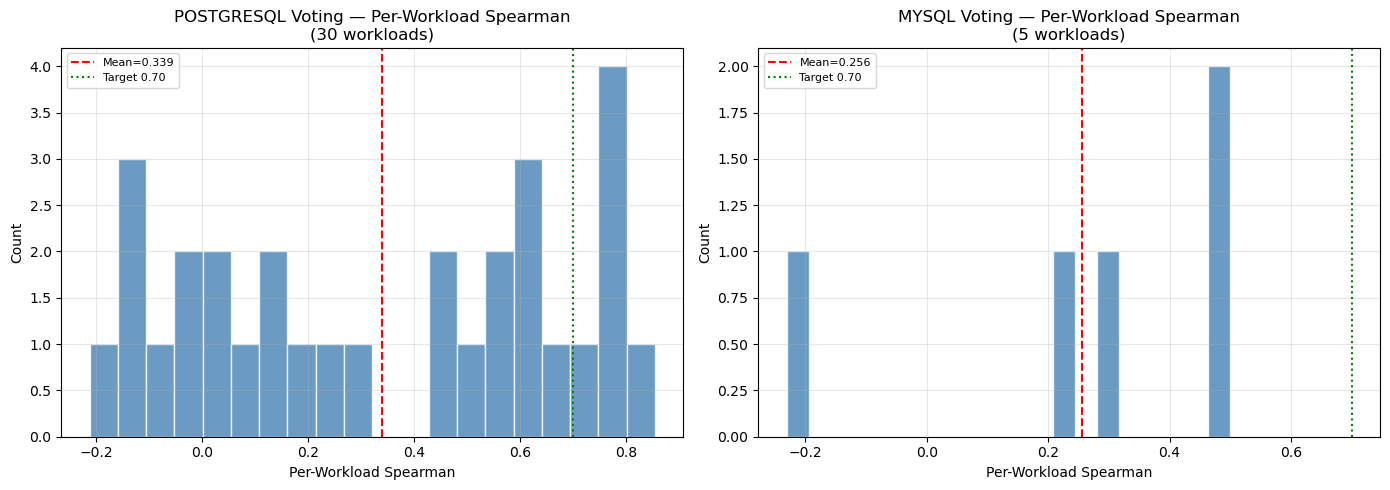

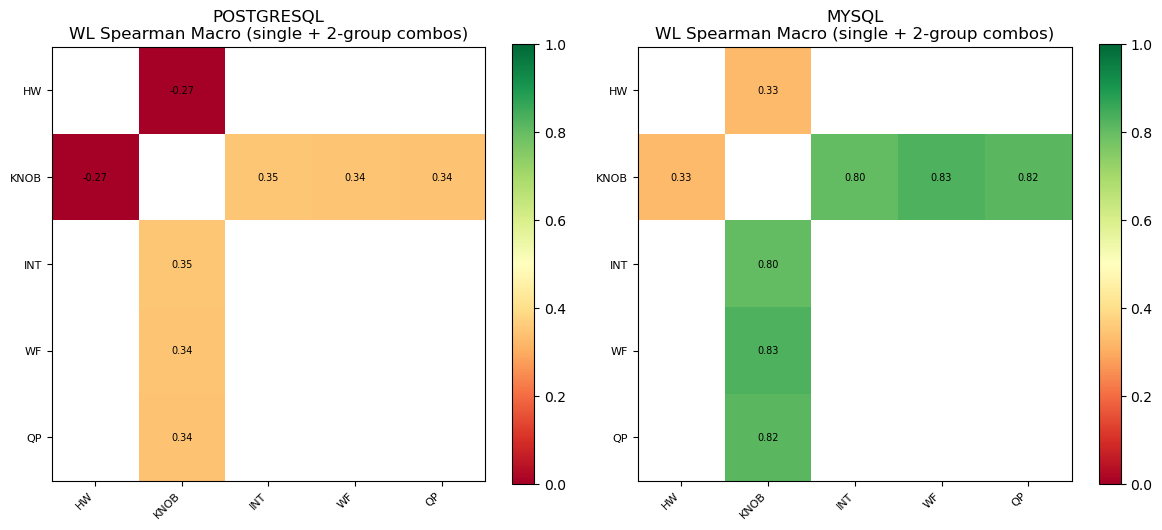

In [47]:
# ── Plot 1: CV vs Test bar chart ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, engine in zip(axes, ['postgresql', 'mysql']):
    models  = ['RF', 'GBM', 'Voting']
    x, w    = np.arange(len(models)), 0.35
    cv_sub  = cv_df[cv_df['engine']==engine]
    te_sub  = summary[summary['engine']==engine]
    cv_m    = [cv_sub[cv_sub['model']==m]['wl_sp_mean'].values[0] for m in models]
    cv_s    = [cv_sub[cv_sub['model']==m]['wl_sp_std'].values[0]  for m in models]
    te_m    = [te_sub[te_sub['model']==m]['wl_sp_macro'].values[0] for m in models]
    ax.bar(x-w/2, cv_m, w, yerr=cv_s, label='CV', color='steelblue', alpha=0.8, capsize=5)
    ax.bar(x+w/2, te_m, w, label='Test', color='coral', alpha=0.8)
    ax.axhline(0.70, color='green', ls='--', lw=1.2, label='Target 0.70')
    ax.set_xticks(x); ax.set_xticklabels(models)
    ax.set_ylabel('Workload Spearman Macro'); ax.set_ylim(0, 1)
    ax.set_title(f'{engine.upper()} — CV vs Test')
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cv_vs_test.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Plot 2: Per-workload Spearman distribution ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, engine, te in zip(axes, ['postgresql','mysql'], [pg_te, my_te]):
    m, imp, cols = TRAINED[(engine, 'Voting')]
    pred = m.predict(imp.transform(te[cols]))
    y_te = te['cost'].to_numpy(); wl_te = te['workload'].to_numpy()
    sps  = [safe_spearman(y_te[wl_te==w], pred[wl_te==w])
             for w in np.unique(wl_te) if (wl_te==w).sum()>=3]
    sps  = [s for s in sps if not np.isnan(s)]
    ax.hist(sps, bins=20, color='steelblue', alpha=0.8, edgecolor='white')
    ax.axvline(np.mean(sps), color='red', ls='--', label=f'Mean={np.mean(sps):.3f}')
    ax.axvline(0.70, color='green', ls=':', lw=1.5, label='Target 0.70')
    ax.set_xlabel('Per-Workload Spearman'); ax.set_ylabel('Count')
    ax.set_title(f'{engine.upper()} Voting — Per-Workload Spearman\n({len(sps)} workloads)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('per_workload_spearman.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Plot 3: Group combination heatmap ─────────────────────────────────────────
# For each engine, show wl_sp of every 2-group combination as a matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
gnames = list(BASE_GROUPS.keys())
for ax, engine in zip(axes, ['postgresql', 'mysql']):
    mat = np.full((len(gnames), len(gnames)), np.nan)
    for i, g1 in enumerate(gnames):
        for j, g2 in enumerate(gnames):
            if i == j:
                # single group score
                row = single_df[(single_df['engine']==engine) &
                                 (single_df['group']==g1)]
                if not row.empty: mat[i,j] = row['wl_sp'].values[0]
            elif i < j:
                key = f'{g1}+{g2}'
                row = combo_df[(combo_df['engine']==engine) & (combo_df['combo']==key)]
                if not row.empty:
                    mat[i,j] = mat[j,i] = row['wl_sp'].values[0]
    im = ax.imshow(mat, cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_xticks(range(len(gnames))); ax.set_xticklabels(gnames, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(gnames))); ax.set_yticklabels(gnames, fontsize=8)
    for i in range(len(gnames)):
        for j in range(len(gnames)):
            if not np.isnan(mat[i,j]):
                ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center', fontsize=7)
    ax.set_title(f'{engine.upper()}\nWL Spearman Macro (single + 2-group combos)')
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('group_combo_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

## 16. Per-Workload Breakdown (Voting — Test Set)

In [48]:
for engine, te in [('postgresql', pg_te), ('mysql', my_te)]:
    m, imp, cols = TRAINED[(engine, 'Voting')]
    # Exponentiate prediction to bring it back to original scale
    pred  = np.expm1(m.predict(imp.transform(te[cols])))
    y_te  = te['cost'].to_numpy()
    wl_te = te['workload'].to_numpy()

    rows = []
    for w in np.unique(wl_te):
        mask = wl_te == w
        rows.append(dict(
            workload = w,
            n        = int(mask.sum()),
            spearman = round(safe_spearman(y_te[mask], pred[mask]), 4),
            pred_std = round(float(pred[mask].std()), 4),
            true_std = round(float(y_te[mask].std()),  4),
            top3_acc = round(top_k_acc(y_te[mask], pred[mask],
                                        np.full(mask.sum(), w)), 4),
        ))

    wl_df = pd.DataFrame(rows).sort_values('n', ascending=False)
    print(f'\n=== {engine.upper()} — Per-Workload (Voting, test) ===')
    print(wl_df.to_string(index=False))
    low_var = (wl_df['pred_std'] < 0.05).sum()
    small_n = (wl_df['n'] < 3).sum()
    if low_var: print(f'  WARNING: {low_var} workloads with near-zero pred_std (model not discriminating)')
    if small_n: print(f'  INFO: {small_n} workloads excluded from macro (n<3)')


=== POSTGRESQL — Per-Workload (Voting, test) ===
                  workload   n  spearman  pred_std  true_std  top3_acc
                     job_1 101   -0.0051    0.0036    0.0212    0.0792
 sample_wikipedia_config10 101    0.1108    0.0012    0.0002    0.0990
                  tpch_256 101    0.7708    0.0605    0.0351    0.1188
                  tpch_140 101    0.7798    0.0507    0.0431    0.2079
                 tpcds_112 101   -0.0747    0.0021    0.0014    0.0594
          ssb_flat_tiny_72 101    0.6141    0.0514    0.2644    0.2277
          ssb_flat_tiny_71 101    0.0064    0.0500    0.0510    0.0495
                   ssb_223 101    0.6188    0.0354    0.0623    0.1386
                    ssb_21 101    0.4343    0.0712    0.1853    0.1287
                   ssb_190 101    0.5461    0.0662    0.1521    0.1683
                   ssb_188 101    0.6409    0.0496    0.0737    0.1683
sample_wikipedia_config170 101    0.1766    0.0009    0.0000    0.0693
sample_wikipedia_config135 